#week05 / DL_diabetes

컴퓨터공학과 / 202433638 / 장영환

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    mean_squared_error, mean_absolute_error, r2_score
)

path = '/content/drive/MyDrive/Colab Notebooks/인공지능개론/week02/diabetes.csv'
df = pd.read_csv(path)

y=df['Outcome']
X=df.drop('Outcome',axis=1)

분류
accuracy
confusion matrix
precision
recall
F1


회귀
MSE
MAE
RMSE
R²

In [ ]:
print("데이터 shape:", df.shape)
print(df.head())
print("\n컬럼별 데이터 타입:")
print(df.dtypes)
print("\n기본 통계:")
print(df.describe())
print("\n결측치 확인:")
print(df.isnull().sum())

데이터 shape: (768, 9)
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

컬럼별 데이터 타입:
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age               

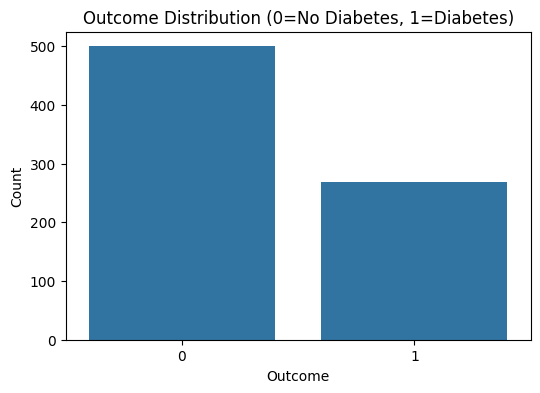

Outcome 분포:
 Outcome
0    500
1    268
Name: count, dtype: int64

0값 개수 (결측치로 의심):
  Glucose: 5개
  BloodPressure: 35개
  SkinThickness: 227개
  Insulin: 374개
  BMI: 11개

전처리 후 0값 확인:
  Glucose: 0개
  BloodPressure: 0개
  SkinThickness: 0개
  Insulin: 0개
  BMI: 0개


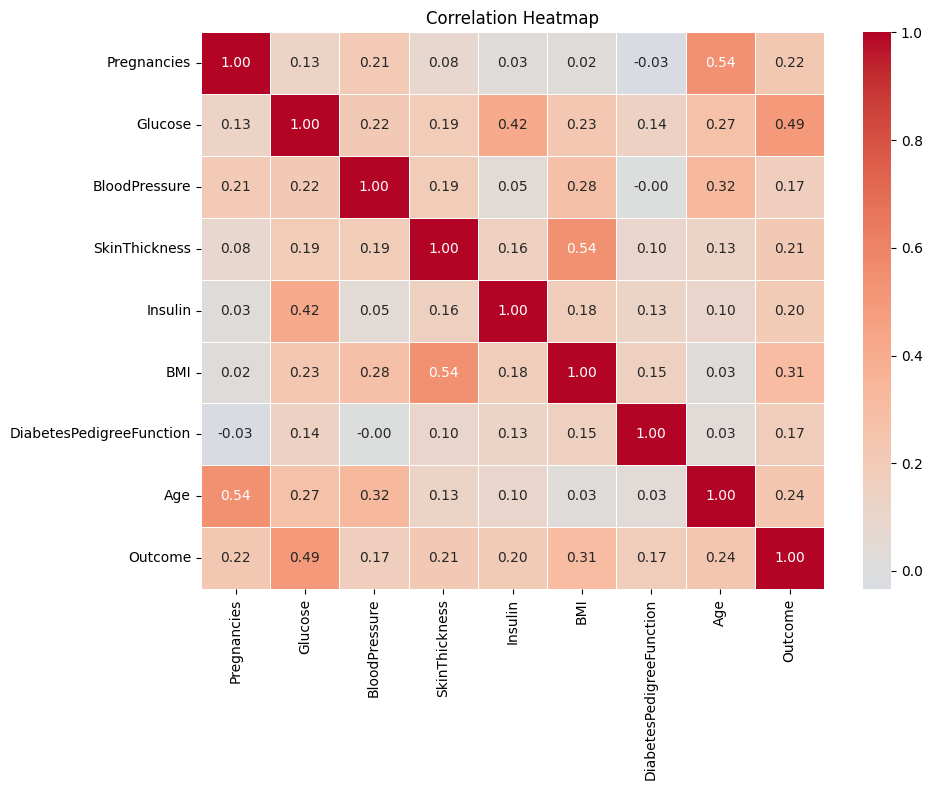

/tmp/ipykernel_4523/968925659.py:37: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  df_clean.hist(ax=ax, bins=20, edgecolor='black')


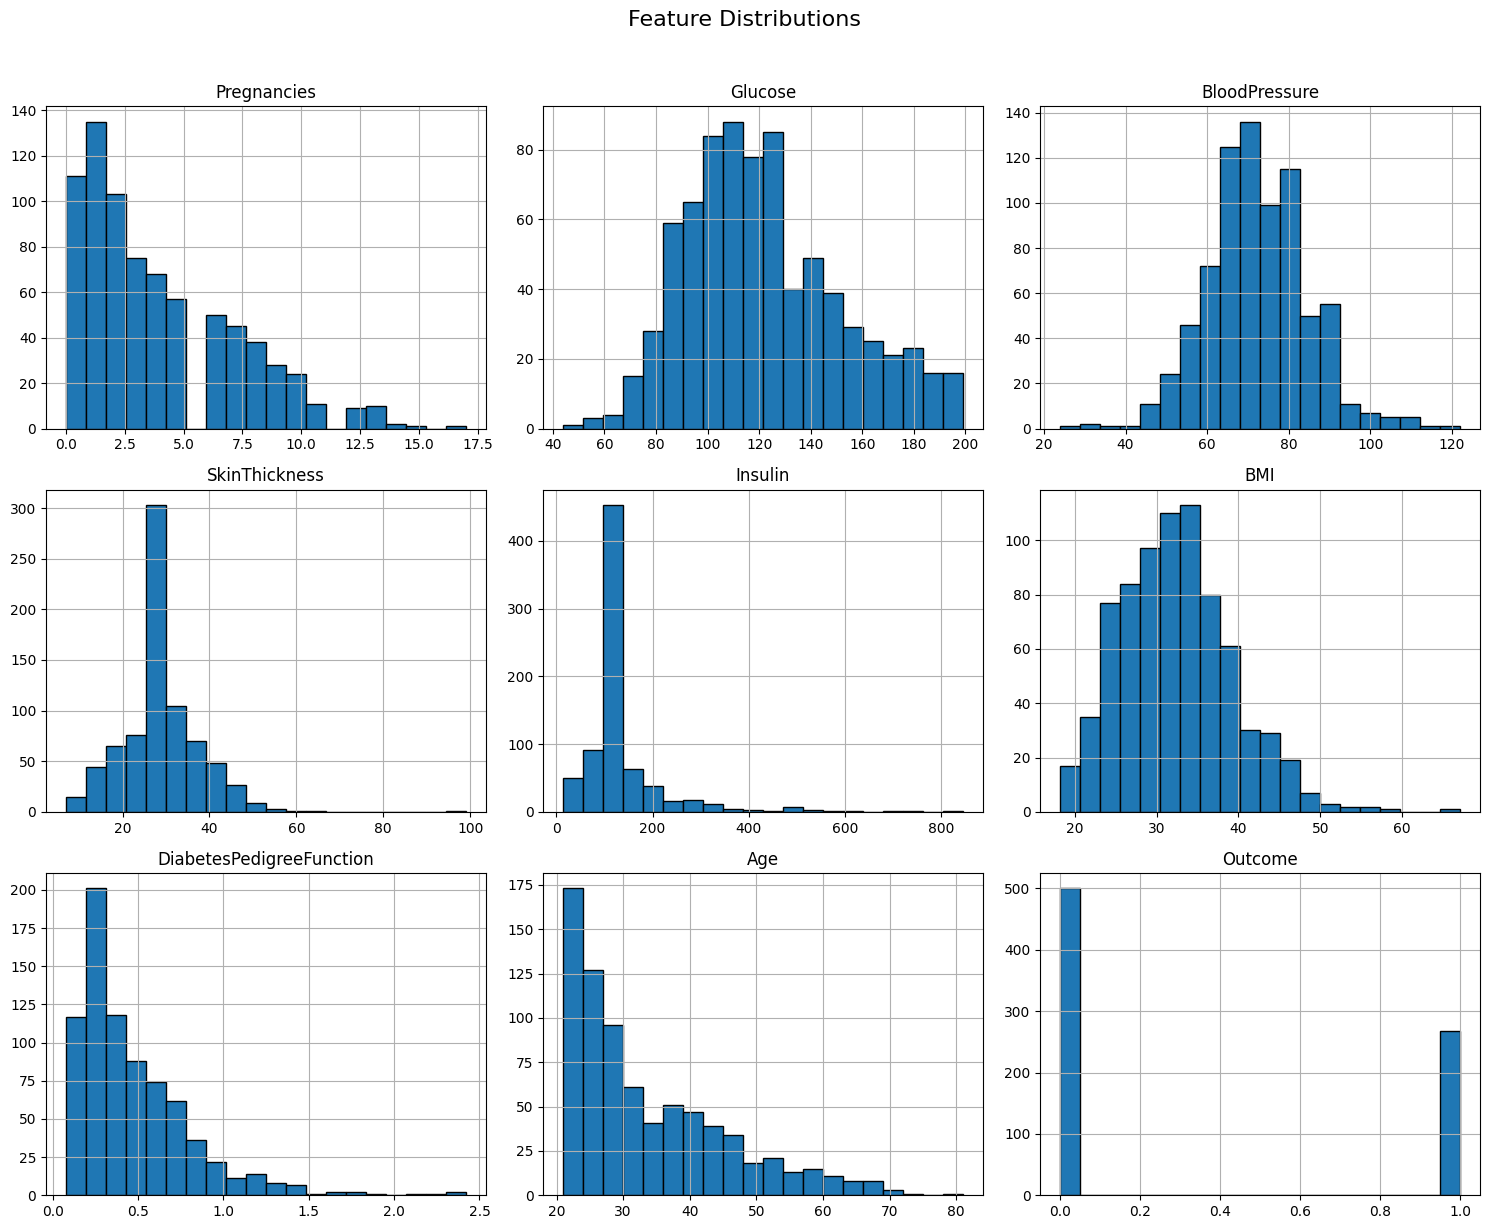

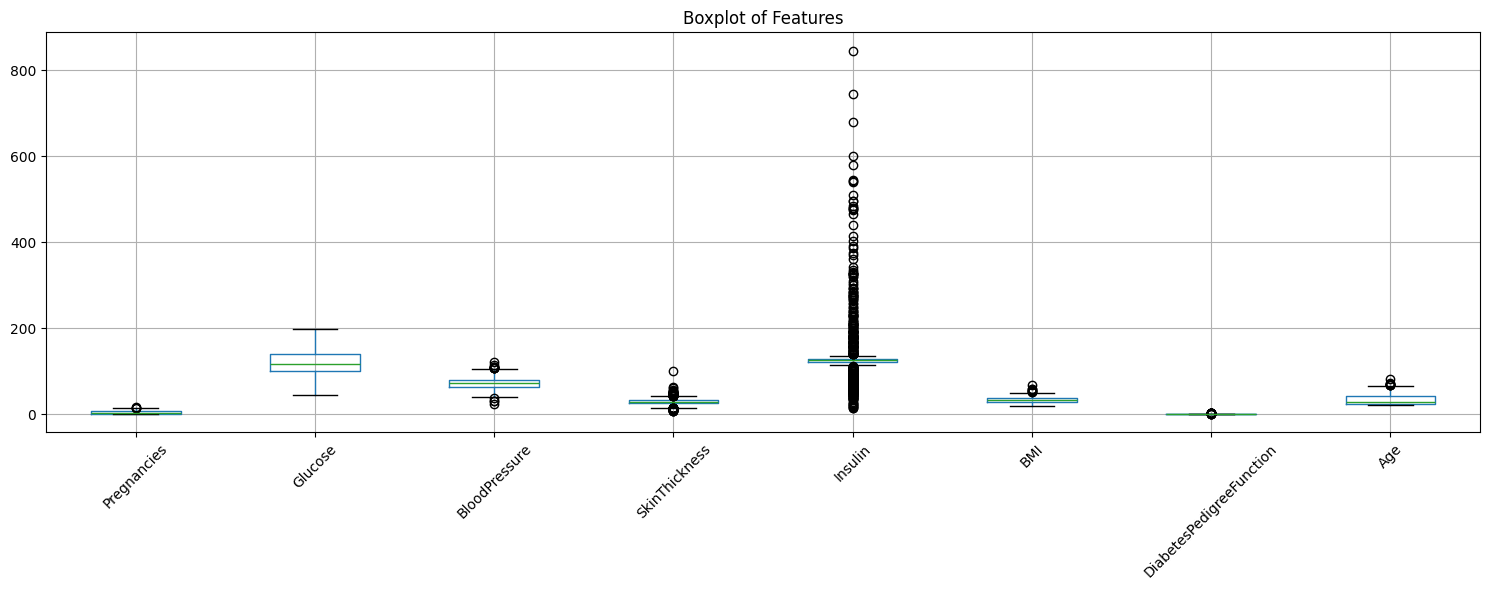

In [ ]:
# 타겟(Outcome) 분포 확인
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Outcome')
plt.title('Outcome Distribution (0=No Diabetes, 1=Diabetes)')
plt.xlabel('Outcome')
plt.ylabel('Count')
plt.show()
print("Outcome 분포:\n", df['Outcome'].value_counts())

# 0값 확인 (결측치로 의심되는 컬럼들)
# Glucose, BloodPressure, SkinThickness, Insulin, BMI에서 0은 의학적으로 불가능 → 결측치
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
print("\n0값 개수 (결측치로 의심):")
for col in zero_cols:
    print(f"  {col}: {(df[col] == 0).sum()}개")

# 0값을 NaN으로 변환 후 중앙값으로 대체
df_clean = df.copy()
df_clean[zero_cols] = df_clean[zero_cols].replace(0, np.nan)
df_clean[zero_cols] = df_clean[zero_cols].fillna(df_clean[zero_cols].median())

print("\n전처리 후 0값 확인:")
for col in zero_cols:
    print(f"  {col}: {(df_clean[col] == 0).sum()}개")

# 상관관계 히트맵
plt.figure(figsize=(10, 8))
sns.heatmap(df_clean.corr(), annot=True, cmap='coolwarm', fmt='.2f',
            linewidths=0.5, center=0)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

# 각 컬럼별 히스토그램
fig = plt.figure(figsize=(15, 12))
ax = fig.gca()
df_clean.hist(ax=ax, bins=20, edgecolor='black')
plt.suptitle('Feature Distributions', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# 박스플롯 (이상치 확인)
plt.figure(figsize=(15, 6))
df_clean.drop('Outcome', axis=1).boxplot()
plt.title('Boxplot of Features')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



#Classification

Outcome 예측

학습 데이터: (614, 8), 테스트 데이터: (154, 8)
학습 레이블 분포:
Outcome
0    400
1    214
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_56 (Dense)                │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_57 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_58 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_59 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,201 (12.50 KB)

 Trainable params: 3,201 (12.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.6415 - loss: 0.6590 - val_accuracy: 0.6504 - val_loss: 0.6158
Epoch 2/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6558 - loss: 0.5910 - val_accuracy: 0.6911 - val_loss: 0.5545
Epoch 3/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7352 - loss: 0.5209 - val_accuracy: 0.7317 - val_loss: 0.5154
Epoch 4/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7495 - loss: 0.4992 - val_accuracy: 0.7805 - val_loss: 0.5016
Epoch 5/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7576 - loss: 0.4851 - val_accuracy: 0.7805 - val_loss: 0.5073
Epoch 6/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7821 - loss: 0.4671 - val_accuracy: 0.7724 - val_loss: 0.5107
Epoch 7/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7658 - loss: 0.4729 - val_accuracy: 0.7480 - val_loss: 0.5208
Epoch 8/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7719 - loss: 0.4547 - val_accuracy: 0.7561 - 

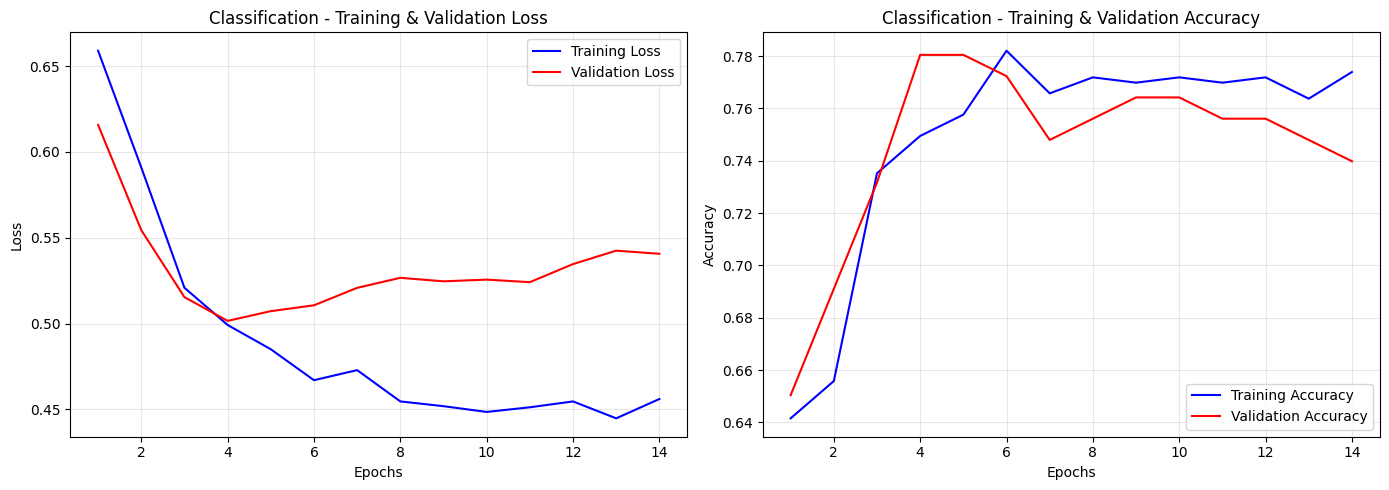

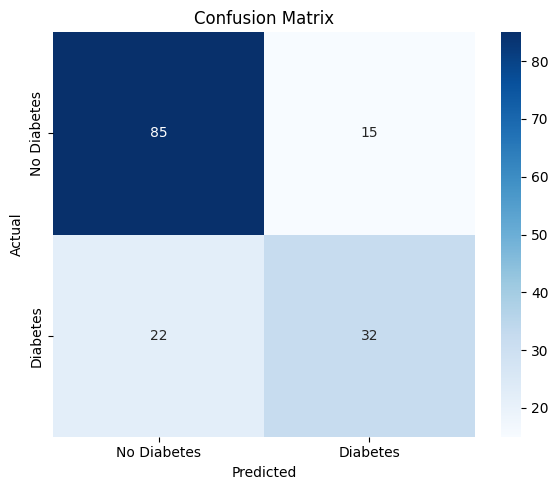

In [ ]:
# 분류 데이터 준비

X_cls = df_clean.drop('Outcome', axis=1)
y_cls = df_clean['Outcome']

# 스케일링
scaler_cls = StandardScaler()
X_cls_scaled = scaler_cls.fit_transform(X_cls)

# 학습/테스트 분리 (stratify로 클래스 비율 유지)
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cls_scaled, y_cls, test_size=0.2, random_state=0, stratify=y_cls
)

print(f"학습 데이터: {X_train_c.shape}, 테스트 데이터: {X_test_c.shape}")
print(f"학습 레이블 분포:\n{pd.Series(y_train_c).value_counts()}")


#  분류 모델 정의 & 학습

model_cls = models.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train_c.shape[1],)),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),          # ← 추가: 과적합 방지를 위한 드롭아웃
    layers.Dense(16, activation='relu'),  # ← 추가: 레이어 하나 더
    layers.Dense(1, activation='sigmoid')
])

model_cls.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_cls.summary()

# EarlyStopping 콜백 추가
early_stop_cls = EarlyStopping(
    monitor='val_loss',
    patience=10,           # 10 에폭 동안 개선 없으면 중단
    restore_best_weights=True,
    verbose=1
)

history_cls = model_cls.fit(
    X_train_c, y_train_c,
    validation_split=0.2,
    epochs=100,            # ← 50 → 100으로 늘리되, EarlyStopping이 알아서 중단
    batch_size=16,
    callbacks=[early_stop_cls],
    verbose=1
)


# 분류 결과 평가

y_pred_c = model_cls.predict(X_test_c)
y_pred_class_c = (y_pred_c > 0.5).astype(int).flatten()

print("\nClassification Report:")
print(classification_report(y_test_c, y_pred_class_c,
                            target_names=['No Diabetes(0)', 'Diabetes(1)']))

print("Confusion Matrix:")
cm = confusion_matrix(y_test_c, y_pred_class_c)
print(cm)


# 분류 시각화


# 학습 곡선 (Loss)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_cls = range(1, len(history_cls.history['loss']) + 1)

axes[0].plot(epochs_cls, history_cls.history['loss'], 'b-', label='Training Loss')
axes[0].plot(epochs_cls, history_cls.history['val_loss'], 'r-', label='Validation Loss')
axes[0].set_title('Classification - Training & Validation Loss')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 학습 곡선 (Accuracy)
axes[1].plot(epochs_cls, history_cls.history['accuracy'], 'b-', label='Training Accuracy')
axes[1].plot(epochs_cls, history_cls.history['val_accuracy'], 'r-', label='Validation Accuracy')
axes[1].set_title('Classification - Training & Validation Accuracy')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 혼동행렬 히트맵
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()



#Regression

BMI 예측

학습 데이터: (614, 7), 테스트 데이터: (154, 7)
BMI 통계:
count    768.000000
mean      32.455208
std        6.875177
min       18.200000
25%       27.500000
50%       32.300000
75%       36.600000
max       67.100000
Name: BMI, dtype: float64


<>:63: SyntaxWarning: invalid escape sequence '\R'
<>:63: SyntaxWarning: invalid escape sequence '\R'
/tmp/ipykernel_4523/1303886447.py:63: SyntaxWarning: invalid escape sequence '\R'
  print("\Regression Evaluation Metrics:")
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_60 (Dense)                │ (None, 64)             │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_28 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_61 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_29 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_62 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_63 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,137 (12.25 KB)

 Trainable params: 3,137 (12.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 1103.8588 - mae: 32.5002 - val_loss: 1060.1149 - val_mae: 31.7714
Epoch 2/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1012.6291 - mae: 31.0809 - val_loss: 902.1775 - val_mae: 29.2495
Epoch 3/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 754.0256 - mae: 26.4717 - val_loss: 500.4631 - val_mae: 21.3986
Epoch 4/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 320.7012 - mae: 15.9214 - val_loss: 97.2825 - val_mae: 8.3127
Epoch 5/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 138.6326 - mae: 9.4162 - val_loss: 65.0589 - val_mae: 6.6800
Epoch 6/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 121.7158 - mae: 8.8079 - val_loss: 60.7318 - val_mae: 6.4568
Epoch 7/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 113.7348 - mae: 8.2309 - val_loss: 58.3650 - val_mae: 6.2795
Epoch 8/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 104.6185 - mae: 8.0646 - val_loss: 55.7960 - val_mae: 6.1572
Epoch 9/100
31/31 ━━━━━━━━

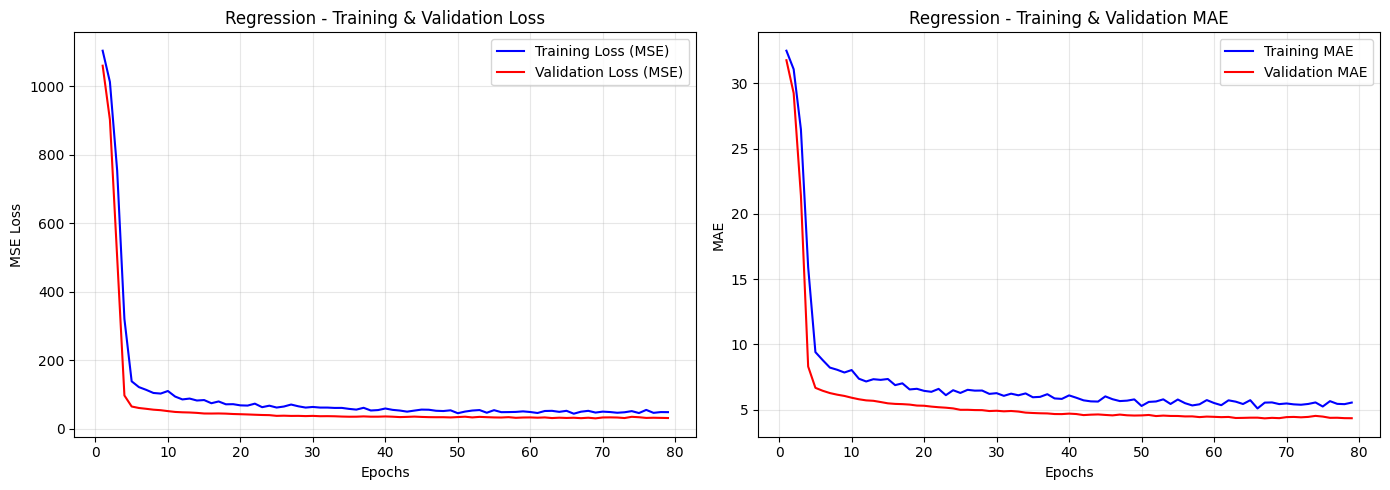

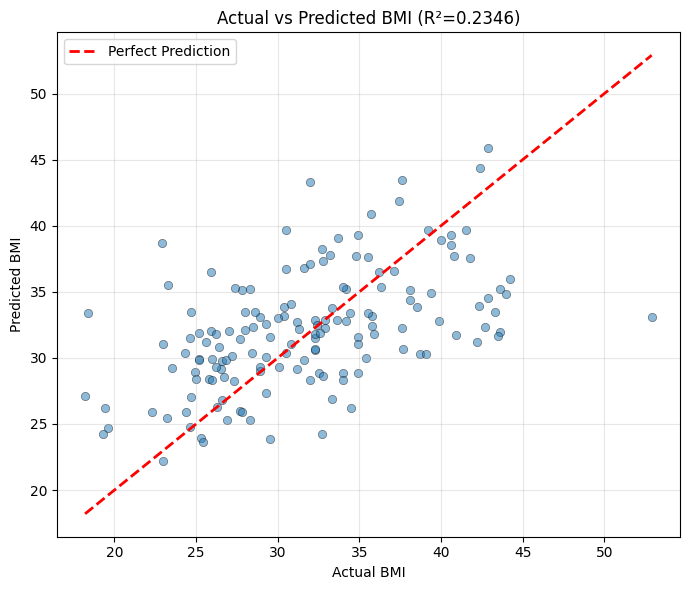

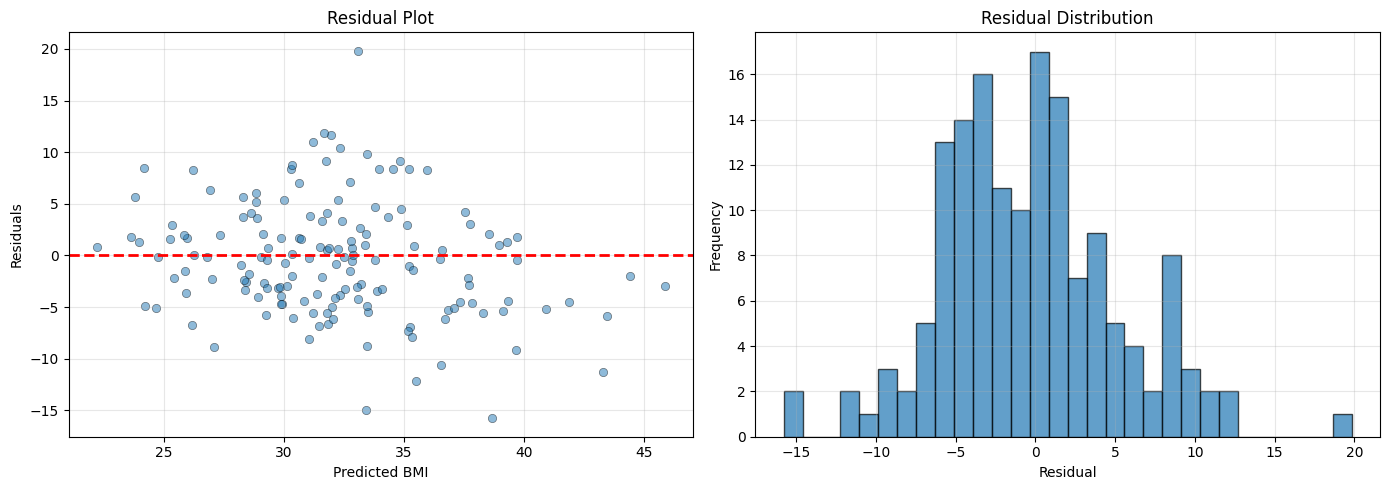

In [ ]:
# 회귀 데이터 준비
# BMI를 타겟으로, Outcome과 BMI를 제외한 나머지를 피처로 사용
X_reg = df_clean.drop(['Outcome', 'BMI'], axis=1)
y_reg = df_clean['BMI']

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=0
)

# 스케일링 (학습 데이터로 fit, 테스트 데이터는 transform만)
scaler_reg = StandardScaler()
X_train_r_scaled = scaler_reg.fit_transform(X_train_r)
X_test_r_scaled = scaler_reg.transform(X_test_r)

print(f"학습 데이터: {X_train_r_scaled.shape}, 테스트 데이터: {X_test_r_scaled.shape}")
print(f"BMI 통계:\n{y_reg.describe()}")


# 회귀 모델 정의 & 학습
model_reg = models.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train_r_scaled.shape[1],)),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(16, activation='relu'),
    layers.Dense(1)  # 회귀이므로 활성화 함수 없음 (선형 출력)
])

model_reg.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

model_reg.summary()

# EarlyStopping 콜백
early_stop_reg = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

history_reg = model_reg.fit(
    X_train_r_scaled, y_train_r,
    validation_split=0.2,
    epochs=100,
    batch_size=16,
    callbacks=[early_stop_reg],
    verbose=1
)


# 회귀 결과 평가
y_pred_r = model_reg.predict(X_test_r_scaled).flatten()

mse  = mean_squared_error(y_test_r, y_pred_r)
mae  = mean_absolute_error(y_test_r, y_pred_r)
rmse = np.sqrt(mse)
r2   = r2_score(y_test_r, y_pred_r)

print("\Regression Evaluation Metrics:")
print(f"  MSE  : {mse:.4f}")
print(f"  RMSE : {rmse:.4f}")
print(f"  MAE  : {mae:.4f}")
print(f"  R²   : {r2:.4f}")


# 회귀 시각화
# 학습 곡선 (Loss & MAE)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_reg = range(1, len(history_reg.history['loss']) + 1)

axes[0].plot(epochs_reg, history_reg.history['loss'], 'b-', label='Training Loss (MSE)')
axes[0].plot(epochs_reg, history_reg.history['val_loss'], 'r-', label='Validation Loss (MSE)')
axes[0].set_title('Regression - Training & Validation Loss')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('MSE Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_reg, history_reg.history['mae'], 'b-', label='Training MAE')
axes[1].plot(epochs_reg, history_reg.history['val_mae'], 'r-', label='Validation MAE')
axes[1].set_title('Regression - Training & Validation MAE')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('MAE')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 실제 vs 예측 산점도
plt.figure(figsize=(7, 6))
plt.scatter(y_test_r, y_pred_r, alpha=0.5, edgecolors='k', linewidths=0.5)
plt.plot([y_test_r.min(), y_test_r.max()],
         [y_test_r.min(), y_test_r.max()],
         'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual BMI')
plt.ylabel('Predicted BMI')
plt.title(f'Actual vs Predicted BMI (R²={r2:.4f})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 잔차(Residual) 분포
residuals = y_test_r - y_pred_r

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_pred_r, residuals, alpha=0.5, edgecolors='k', linewidths=0.5)
axes[0].axhline(y=0, color='r', linestyle='--', lw=2)
axes[0].set_xlabel('Predicted BMI')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residual Plot')
axes[0].grid(True, alpha=0.3)

axes[1].hist(residuals, bins=30, edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Residual Distribution')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()